In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [30]:
img_size = 224
batch_size = 32

In [31]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [48]:
train_generator = train_datagen.flow_from_directory(
    'archive (1)\brain_tumor_dataset',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

OSError: [WinError 123] The filename, directory name, or volume label syntax is incorrect: 'archive (1)\x08rain_tumor_dataset'

In [ ]:
val_generator = train_datagen.flow_from_directory(
    'archive (1)',
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 1120 images belonging to 4 classes.


In [20]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dense(2, activation='softmax'))

In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
num_classes = train_generator.num_classes
print(num_classes)

4


In [23]:
from tensorflow.keras.layers import Dense
model.add(Dense(num_classes, activation='softmax'))

In [24]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.2540 - loss: 1.4678 - val_accuracy: 0.2500 - val_loss: 1.4236
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 709ms/step - accuracy: 0.2547 - loss: 1.4122 - val_accuracy: 0.2500 - val_loss: 1.3978
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.2447 - loss: 1.3962 - val_accuracy: 0.2500 - val_loss: 1.3895
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 129s 923ms/step - accuracy: 0.2520 - loss: 1.3879 - val_accuracy: 0.2500 - val_loss: 1.3870
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 100s 716ms/step - accuracy: 0.2670 - loss: 1.3856 - val_accuracy: 0.2500 - val_loss: 1.3865
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 673ms/step - accuracy: 0.2438 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 637ms/step - accuracy: 0.2350 - loss: 1.3866 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 661ms/step - accuracy: 0.2413 - loss: 1

In [25]:
loss, accuracy = model.evaluate(val_generator)
print('Validation Accuracy:', accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - accuracy: 0.2368 - loss: 1.3864
Validation Accuracy: 0.25


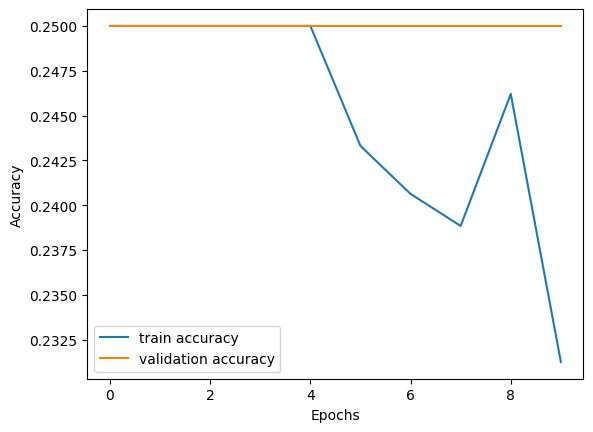

In [26]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()